In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    RandomRotation,
    Conv2D,
    ZeroPadding2D,
    MaxPooling2D,
    Flatten,
    Dense
)

import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


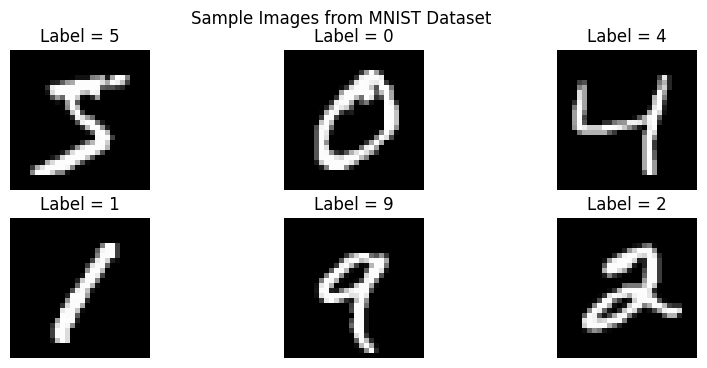

In [5]:
plt.figure(figsize=(10,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label = {}".format(y_train[i]))
    plt.axis("off")

plt.suptitle("Sample Images from MNIST Dataset")
plt.show()

In [6]:
print("Before Conversion")
print("Shape :", x_train.shape)
print("Data Type :", x_train.dtype)
print("Pixel Range :", x_train.min(), "to", x_train.max())

Before Conversion
Shape : (60000, 28, 28)
Data Type : uint8
Pixel Range : 0 to 255


In [7]:
# Reshape images

x_train = x_train.reshape(-1,28,28,1).astype("float32")
x_test = x_test.reshape(-1,28,28,1).astype("float32")

In [8]:
print("After Conversion")
print("Shape :", x_train.shape)
print("Data Type :", x_train.dtype)

After Conversion
Shape : (60000, 28, 28, 1)
Data Type : float32


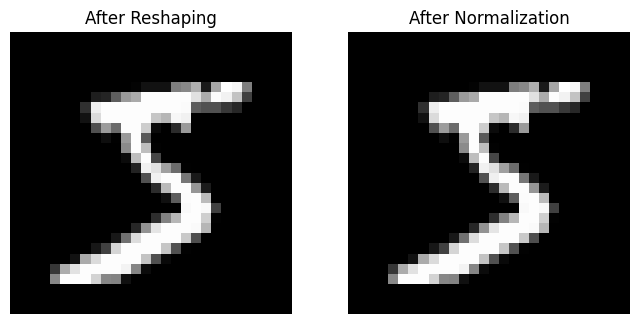

In [9]:
fig, ax = plt.subplots(1,2, figsize=(8,4))

# Original Image
ax[0].imshow(x_train[0].reshape(28,28), cmap='gray')
ax[0].set_title("After Reshaping")
ax[0].axis("off")

# Normalized Preview
ax[1].imshow((x_train[0]/255.0).reshape(28,28), cmap='gray')
ax[1].set_title("After Normalization")
ax[1].axis("off")

plt.show()

In [10]:
model = Sequential([

    Input(shape=(28,28,1)),

    # Normalization Layer
    Rescaling(1./255),

    # Data Augmentation
    RandomRotation(0.10),

    # CNN Layer
    Conv2D(32,(3,3),activation='relu'),

    # Padding Layer
    ZeroPadding2D(padding=(1,1)),

    # Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(10,activation='softmax')

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9305 - loss: 0.2218 - val_accuracy: 0.9770 - val_loss: 0.0813
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9739 - loss: 0.0834 - val_accuracy: 0.9822 - val_loss: 0.0617
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9810 - loss: 0.0608 - val_accuracy: 0.9849 - val_loss: 0.0519
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9839 - loss: 0.0509 - val_accuracy: 0.9847 - val_loss: 0.0526
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9878 - val_loss: 0.0405
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9877 - loss: 0.0392 - val_accuracy: 0.9878 - val_loss: 0.0391
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9875 - val_loss: 0.0406
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 

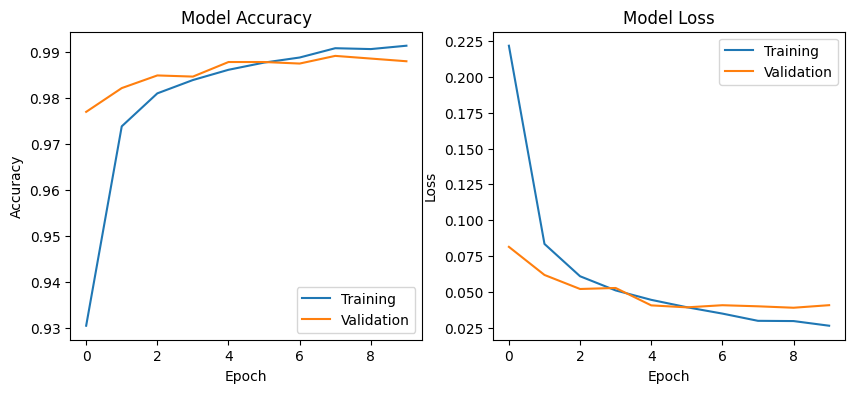

In [13]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
loss, accuracy = model.evaluate(x_test,y_test)

print("Test Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0382
Test Accuracy = 0.9878000020980835


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


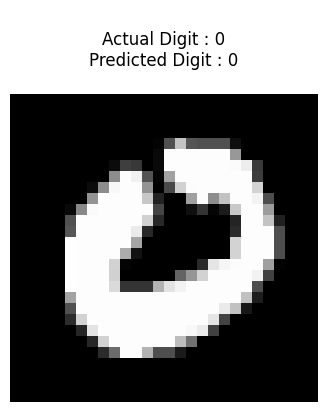

In [15]:
index = 25

image = x_test[index]

prediction = model.predict(np.expand_dims(image,axis=0))
predicted_digit = np.argmax(prediction)

plt.figure(figsize=(4,4))
plt.imshow(image.squeeze(),cmap='gray')

plt.title(f"""
Actual Digit : {y_test[index]}
Predicted Digit : {predicted_digit}
""")

plt.axis('off')
plt.show()